## Analysis of green development in Copenhagen

## Dependencies

Run "!pip install -r requirements.txt" to install required libraries.

In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.impute import SimpleImputer
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

## Main program

### Loading dataset

In [247]:
df = pd.read_csv("../data/trae_basis.csv")
df = df.set_index("FID")
df.head()

/tmp/ipykernel_719439/1446104451.py:1: DtypeWarning: Columns (51,57,58,59,60,69,70,71,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/trae_basis.csv")


,uuid,id,kategori,saerligt_trae,type,element,under_element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,...,torso_frekvens_styning,torso_naeste_styning,torso_skaeres_ned_til,torso_bemaerkning,seneste_beskaering_aar,frekvens_beskaering,naeste_beskaering_aar,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,2.1.1 Gadetræer,Gade- og allétræer,Allétræ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,NaN,Gade- og allétræer,Gadetræ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540942745348927 55.66559139825601)


### Changing non registered values to NaN

In [248]:
df = df.replace("Ikke registreret", np.nan)
df.head()

,uuid,id,kategori,saerligt_trae,type,element,under_element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,...,torso_frekvens_styning,torso_naeste_styning,torso_skaeres_ned_til,torso_bemaerkning,seneste_beskaering_aar,frekvens_beskaering,naeste_beskaering_aar,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,2.1.1 Gadetræer,Gade- og allétræer,Allétræ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,NaN,Gade- og allétræer,Gadetræ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540942745348927 55.66559139825601)


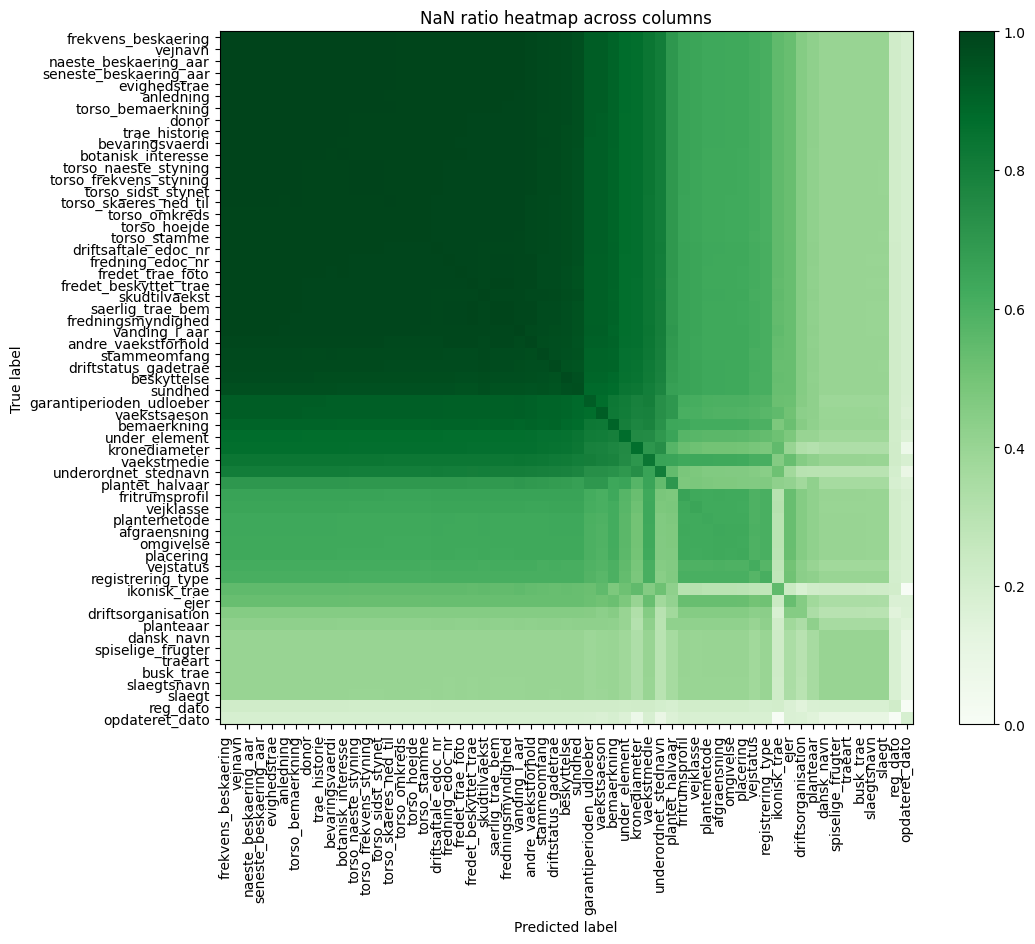

,nan_share
frekvens_beskaering,1.000000
vejnavn,1.000000
naeste_beskaering_aar,1.000000
seneste_beskaering_aar,1.000000
evighedstrae,0.999985
anledning,0.999529
torso_bemaerkning,0.999500
donor,0.999029
trae_historie,0.998735
bevaringsvaerdi,0.997838


In [249]:
nan_ratio = df.isna().mean().sort_values(ascending=False)
min_nan_share = 0.1
nan_ratio_filtered = nan_ratio[nan_ratio >= min_nan_share]

nan_mask = df[nan_ratio_filtered.index].isna().astype(int)
co_missing_share = (nan_mask.T @ nan_mask) / len(df)

fig, ax = plt.subplots(figsize=(12, 9))
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=co_missing_share.values,
    display_labels=co_missing_share.columns,
)
cm_display.plot(ax=ax, cmap="Greens", colorbar=True, include_values=False, xticks_rotation=90)
ax.set_title("NaN ratio heatmap across columns")
plt.show()

nan_ratio_filtered.to_frame("nan_share")

### Analysis of tree amount over time

In [250]:
nan_year_trees = []
for row in df.index:
    if np.isnan(df.loc[row, "planteaar"]): #type: ignore
        nan_year_trees.append(row)
df = df.drop(nan_year_trees)
df

,uuid,id,kategori,saerligt_trae,type,element,under_element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,...,torso_frekvens_styning,torso_naeste_styning,torso_skaeres_ned_til,torso_bemaerkning,seneste_beskaering_aar,frekvens_beskaering,naeste_beskaering_aar,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,2.1.1 Gadetræer,Gade- og allétræer,Allétræ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,gadetræ,nej,2 Træer,2.2 Specialformede træer,2.2.2 Knudebeskårne træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,NaN,Gade- og allétræer,Gadetræ,Gadet_Gadet_3421,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.540942745348927 55.66559139825601)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67928,40e2da87-cf18-40cc-ad61-887209e95331,91699,parktræ,nej,2 Træer,Park- og naturtræer,Parktræ,Park- og naturtræer,Parktræ,Remis_Remis_477,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.594258860893818 55.65107459300965)
trae_basis.67931,bf966919-b454-4450-a6c3-41282d1e9e9c,91723,parktræ,nej,2 Træer,Park- og naturtræer,Parktræ,Park- og naturtræer,Parktræ,Remis_Remis_477,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.594424160294265 55.65097845524675)
trae_basis.67939,5e4c6e21-8b54-4c78-b221-a931ac96fae8,91880,parktræ,nej,2 Træer,Park- og naturtræer,Parktræ,Park- og naturtræer,Parktræ,Remis_Remis_477,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nej,nej,POINT (12.59605672433198 55.65239601367538)


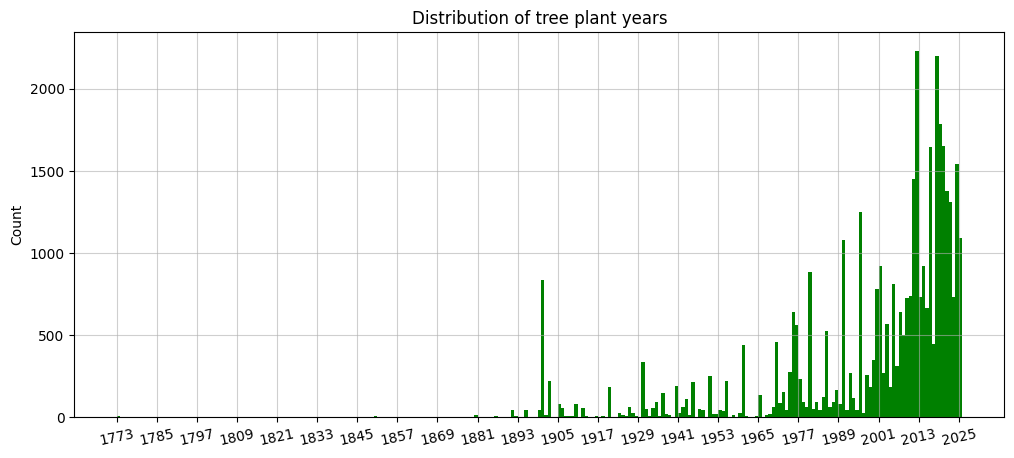

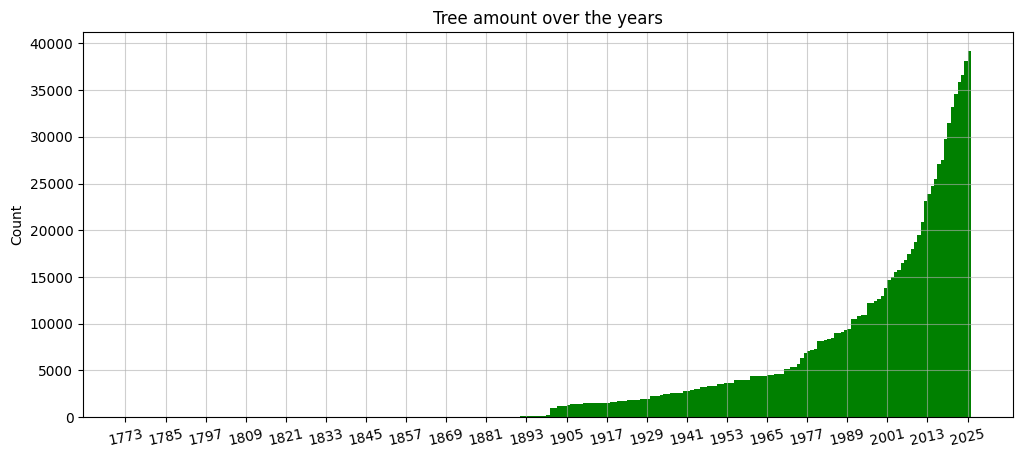

In [251]:
plant_years = df.loc[:, "planteaar"]
plant_years.replace(2027, 2026, inplace=True)
oldest_tree_year = min(plant_years)
youngest_tree_year = max(plant_years)
plant_year_range = youngest_tree_year-oldest_tree_year

plt.figure(figsize=[12, 5])
plt.hist(plant_years, bins=int(plant_year_range), color="green")
plt.title("Distribution of tree plant years")
plt.ylabel("Count")
plt.xticks(np.arange(oldest_tree_year, youngest_tree_year, step=12), rotation=12)
plt.grid(alpha=0.6)
plt.savefig("../data/dist.png")
plt.show()

plt.figure(figsize=[12, 5])
plt.hist(plant_years, bins=int(plant_year_range), color="green", cumulative=True)
plt.title("Tree amount over the years")
plt.ylabel("Count")
plt.xticks(np.arange(oldest_tree_year, youngest_tree_year, step=12), rotation=12)
plt.grid(alpha=0.6)
plt.savefig("../data/cumu.png")
plt.show()

## Preprocessing and model training

### Impution of unknown tree plant years

In [252]:
df = pd.read_csv("../data/trae_basis.csv")
df = df.set_index("FID")
df = df.dropna(axis=1, thresh=round(len(df.index) / 2))

target_col = "planteaar"
non_features = ["uuid", "id", target_col]
features = df.columns.drop(non_features, errors="ignore")

def impute_features(df: pd.DataFrame) -> pd.DataFrame:
    feature_imputer = SimpleImputer(strategy="most_frequent")
    df_imputed = df.copy()
    df_imputed.loc[:, features] = feature_imputer.fit_transform(df_imputed.loc[:, features])
    return df_imputed

df = impute_features(df)
df

/tmp/ipykernel_719439/3165347785.py:1: DtypeWarning: Columns (51,57,58,59,60,69,70,71,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/trae_basis.csv")


,uuid,id,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,driftsplan_navn,...,fredet_beskyttet_trae,fredningsmyndighed,trae_historie,botanisk_interesse,evighedstrae,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Allétræ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2022-02-22T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540942745348927 55.66559139825601)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67987,66c47ec8-92b9-4ac1-ad82-84bbb8d41d1b,40458,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,Kastrup Fort,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2023-08-15T10:15:15.213,nej,nej,POINT (12.637993510679758 55.65042538791118)
trae_basis.67988,af2366e2-c365-447b-98d1-d38e0241de30,40476,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Bella_Bella_284,Bellahøjmarken_Cirkuspladsen,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2023-08-15T10:15:15.213,nej,nej,POINT (12.518204874052591 55.70208340192709)
trae_basis.67989,d0cb241f-7a78-4717-9759-3e49b1041e1f,40439,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,Kastrup Fort,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2023-08-15T10:15:15.213,nej,nej,POINT (12.639966830590264 55.650495149618195)


### Unique feature overview

In [253]:
for feature in features:
    print(f"{feature}: {len(df[feature].unique())}")

kategori: 4
saerligt_trae: 2
type: 2
element: 9
ny_dm_element: 8
ny_dm_under_element: 12
arbsted_tekst_id: 278
driftsplan_navn: 101
traeart: 576
dansk_navn: 467
slaegt: 122
slaegtsnavn: 111
plantet_halvaar: 3
busk_trae: 2
spiselige_frugter: 4
bydelsnavn: 10
lokaludvalg: 12
byrumstype: 6
underordnet_byrumstype: 13
stednavn: 533
vejklasse: 7
fritrumsprofil: 4
stammeomfang: 8
kronediameter: 7
placering: 8
afgraensning: 3
plantemetode: 14
omgivelse: 7
vaekstmedie: 5
luftfyldt_topbaerelag_plast: 2
beskyttelse: 4
sundhed: 5
skudtilvaekst: 5
bevaringsvaerdi: 8
registrering_type: 9
driftstatus_gadetrae: 6
garantiperioden_udloeber: 17
vanding_i_aar: 4
ejer: 4
driftsorganisation: 8
driftsorganisation_vanding: 8
fredet_beskyttet_trae: 3
fredningsmyndighed: 3
trae_historie: 5
botanisk_interesse: 2
evighedstrae: 2
reg_dato: 8535
opdateret_dato: 1115
er_risikotrae: 6
er_flagermusetrae: 2
wkb_geometry: 67710


### Data splitting

In [254]:
X_pred_full = df[np.isnan(df.loc[:, target_col])].copy()
X_pred = X_pred_full.drop(non_features, axis=1)
df = df.drop(X_pred.index)

y = pd.to_numeric(df.loc[:, target_col], errors="coerce")
X = df.drop(non_features, axis=1)

cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
for col in cat_features:
    X[col] = X[col].astype(str)

valid_idx = y.notna()
X = X.loc[valid_idx]
y = y.loc[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)
display(X_train)
display(y_train)

,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,driftsplan_navn,traeart,dansk_navn,...,fredet_beskyttet_trae,fredningsmyndighed,trae_historie,botanisk_interesse,evighedstrae,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.35983,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_2457,Gadetræer Indre by,Tilia europaea,Park-Lind,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2003-04-02T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.589445181231858 55.690576552601144)
trae_basis.63940,parktræ,nej,2 Træer,Træer i bevoksninger,Træer i bevoksninger,Træ i bevoksning,KMC_KMC_3210,KMC,Tilia hybr. europaea 'Pallida',Kejserlind,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2023-01-03T13:59:33.827,2023-08-15T10:15:15.213,nej,nej,POINT (12.520824849957272 55.6182976028914)
trae_basis.37850,parktræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Allétræ,Vestr_Vestr_3035,Vestre Kirkegård,Tilia cordata,Småbladet lind,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2024-09-11T16:01:11.296,2023-08-15T10:15:15.213,nej,nej,POINT (12.52654019016719 55.66054499375556)
trae_basis.52601,parktræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Småpa_Brygg_663,Småparker Østerbro,Metasequoia glyptostroboides,Vandgran,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2019-01-29T09:53:29.999,2022-03-09T17:15:16.581,nej,nej,POINT (12.565167980459908 55.71078019311026)
trae_basis.34205,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_2457,Gadetræer Indre by,Tilia europaea,Park-Lind,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.566644273043014 55.6855309472372)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.9892,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Fælle_Fælle_205,Fælledparken,Quercus robur,Stilk-eg,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2024-04-03T17:08:08.163,nej,nej,POINT (12.567769094459535 55.70300735725664)
trae_basis.19781,parktræ,nej,2 Træer,Park- og naturtræer,Private træer,Privat træ,Vestr_Vestr_3035,Bispebjerg Kirkegård,Malus sieboldii 'Hesse',Japansk prydæble,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2024-09-11T15:19:56.126,2025-03-19T12:30:42.522,nej,nej,POINT (12.523069219178687 55.71391346391072)
trae_basis.64506,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Søstj_1A_3444,Søstjernen,Tilia hybr. europaea 'Pallida',Kejserlind,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2012-04-26T14:41:25,2023-08-15T10:15:15.213,nej,nej,POINT (12.628318619337616 55.66794801511018)


FID
trae_basis.35983    1906.0
trae_basis.63940    2018.0
trae_basis.37850    2016.0
trae_basis.52601    2019.0
trae_basis.34205    1988.0
                     ...  
trae_basis.9892     2012.0
trae_basis.19781    2020.0
trae_basis.64506    2012.0
trae_basis.1641     2000.0
trae_basis.27299    1999.0
Name: planteaar, Length: 31390, dtype: float64

### Training and evaluation on test set

Learning rate set to 0.087477
0:	learn: 28.2519089	test: 28.5671438	best: 28.5671438 (0)	total: 144ms	remaining: 2m 23s
1:	learn: 26.8333513	test: 27.0965088	best: 27.0965088 (1)	total: 232ms	remaining: 1m 55s
2:	learn: 25.5836317	test: 25.8244761	best: 25.8244761 (2)	total: 301ms	remaining: 1m 40s
3:	learn: 24.4489468	test: 24.6615688	best: 24.6615688 (3)	total: 361ms	remaining: 1m 29s
4:	learn: 23.4437702	test: 23.6408374	best: 23.6408374 (4)	total: 427ms	remaining: 1m 24s
5:	learn: 22.5773486	test: 22.7628481	best: 22.7628481 (5)	total: 491ms	remaining: 1m 21s
6:	learn: 21.8092159	test: 21.9643497	best: 21.9643497 (6)	total: 557ms	remaining: 1m 19s
7:	learn: 21.1336482	test: 21.2747746	best: 21.2747746 (7)	total: 619ms	remaining: 1m 16s
8:	learn: 20.4944975	test: 20.6253160	best: 20.6253160 (8)	total: 669ms	remaining: 1m 13s
9:	learn: 19.9331185	test: 20.0511103	best: 20.0511103 (9)	total: 725ms	remaining: 1m 11s
10:	learn: 19.4793409	test: 19.5880759	best: 19.5880759 (10)	total: 77

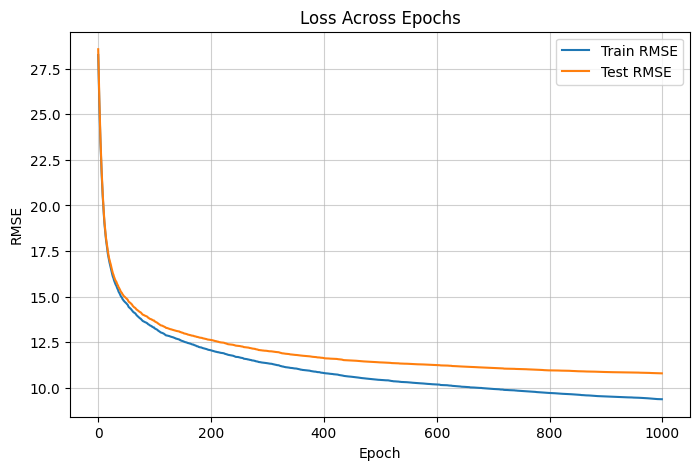

MAE: 5.25 years
RMSE: 10.80 years


In [255]:
model = CatBoostRegressor(
    num_trees=1000,
    loss_function="RMSE",
    verbose=True,
    random_seed=42,
    allow_writing_files=False,
    thread_count=-1,
    cat_features=cat_features,
    early_stopping_rounds=30,
    eval_metric="RMSE",
)

model.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
evals_result = model.get_evals_result()
train_loss = evals_result["learn"]["RMSE"]
test_loss = evals_result["validation"]["RMSE"]

plt.figure(figsize=(8, 5))
plt.plot(train_loss, label="Train RMSE")
plt.plot(test_loss, label="Test RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("Loss Across Epochs")
plt.legend()
plt.grid(alpha=0.6)
plt.show()

print(f"MAE: {mae:.2f} years")
print(f"RMSE: {rmse:.2f} years")

### Running model on NaN plant years and getting complete dataset

In [256]:
X_pred_model = X_pred.copy()
for col in cat_features:
    if col in X_pred_model.columns:
        X_pred_model[col] = X_pred_model[col].astype(str)

y_pred = np.rint(model.predict(X_pred_model)).astype(int)
X_pred_with_target = X_pred_full.copy()
X_pred_with_target[target_col] = y_pred
display(X_pred_with_target)

df_base = df.drop(index=X_pred_with_target.index, errors="ignore")
df = pd.concat([df_base, X_pred_with_target], axis=0)

index_num = pd.to_numeric(
    df.index.to_series().str.extract(r"(\d+)$", expand=False),
    errors="coerce",
)
df = df.loc[index_num.sort_values(kind="stable").index]
display(df)

,uuid,id,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,driftsplan_navn,...,fredet_beskyttet_trae,fredningsmyndighed,trae_historie,botanisk_interesse,evighedstrae,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.8,e96b2933-d8df-4471-abd4-d64f9de40c33,94614,parktræ,nej,2 Træer,2.3 Parktræer,Træer i bevoksninger,Træ i bevoksning,Amage_1B_3450,Amager Strandpark,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2016-10-05T07:26:17.979,2026-03-06T14:24:53.27,nej,nej,POINT (12.637429239229801 55.65761780982644)
trae_basis.16,54466184-a4f5-42de-a223-b51b3e263738,107524,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Småpa_Sundb_196,Småparker Sundbyøster,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2024-09-11T15:29:57.793,2025-03-31T13:35:24.113,nej,nej,POINT (12.612816105913323 55.65654613967322)
trae_basis.24,b2047097-b1c5-4712-ac53-661dc8edaf5e,90786,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Ørste_Ørste_144,Ørstedsparken,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2020-10-07T16:29:04.148,2023-03-07T08:28:55.288,nej,nej,POINT (12.566391609568514 55.68268652388288)
trae_basis.27,e4f904f7-d246-4ea2-a169-c045f93e62ee,83011,parktræ,nej,2 Træer,2.3 Parktræer,Træer i bevoksninger,Træ i bevoksning,Viger_Viger_2250,Vigerslevparken,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2017-02-13T13:27:49.964,2023-08-15T10:15:15.213,nej,nej,POINT (12.487251993243346 55.65164351000413)
trae_basis.28,14275f15-9130-474c-974b-8a3c1babc159,107527,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Sundb_Sundb_3037,Sundby Kirkegård,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2024-09-11T15:29:57.793,2023-08-15T10:15:15.213,nej,nej,POINT (12.616683759742166 55.65697473398831)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67987,66c47ec8-92b9-4ac1-ad82-84bbb8d41d1b,40458,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,Kastrup Fort,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2023-08-15T10:15:15.213,nej,nej,POINT (12.637993510679758 55.65042538791118)
trae_basis.67988,af2366e2-c365-447b-98d1-d38e0241de30,40476,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Bella_Bella_284,Bellahøjmarken_Cirkuspladsen,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2023-08-15T10:15:15.213,nej,nej,POINT (12.518204874052591 55.70208340192709)
trae_basis.67989,d0cb241f-7a78-4717-9759-3e49b1041e1f,40439,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,Kastrup Fort,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2023-08-15T10:15:15.213,nej,nej,POINT (12.639966830590264 55.650495149618195)


,uuid,id,kategori,saerligt_trae,type,element,ny_dm_element,ny_dm_under_element,arbsted_tekst_id,driftsplan_navn,...,fredet_beskyttet_trae,fredningsmyndighed,trae_historie,botanisk_interesse,evighedstrae,reg_dato,opdateret_dato,er_risikotrae,er_flagermusetrae,wkb_geometry
FID,,,,,,,,,,,,,,,,,,,,,
trae_basis.1,0f738310-ec01-4dea-8164-e0b87b463a5a,2669,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.53965126748055 55.665390541095235)
trae_basis.2,938d7fae-9115-4e69-9290-3731e025d208,2676,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.539874779132376 55.66580513321524)
trae_basis.3,c05a9944-b17d-49c8-9c01-e46acca66129,2680,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Allétræ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2022-02-22T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540025124286569 55.66608616293556)
trae_basis.4,84f73fb1-0783-443f-8caa-2ef7941b2bbb,2681,gadetræ,nej,2 Træer,2.2 Specialformede træer,Formede træer,Knudebeskåret træ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540060893478296 55.666150375833226)
trae_basis.5,e42d685e-0bec-42fd-9611-e31e2bc28d5a,6506,gadetræ,nej,2 Træer,2.1 Fuldkronede gade- og torvetræer,Gade- og allétræer,Gadetræ,Gadet_Gadet_3421,Gadetræer Vesterbro-Kgs Enghave,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2022-05-30T16:38:59.623,nej,nej,POINT (12.540942745348927 55.66559139825601)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trae_basis.67987,66c47ec8-92b9-4ac1-ad82-84bbb8d41d1b,40458,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,Kastrup Fort,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2023-08-15T10:15:15.213,nej,nej,POINT (12.637993510679758 55.65042538791118)
trae_basis.67988,af2366e2-c365-447b-98d1-d38e0241de30,40476,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Bella_Bella_284,Bellahøjmarken_Cirkuspladsen,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2023-08-15T10:15:15.213,nej,nej,POINT (12.518204874052591 55.70208340192709)
trae_basis.67989,d0cb241f-7a78-4717-9759-3e49b1041e1f,40439,parktræ,nej,2 Træer,2.3 Parktræer,Park- og naturtræer,Parktræ,Kastr_Kastr_393,Kastrup Fort,...,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,Ikke registreret,2011-07-01T00:00:00,2023-08-15T10:15:15.213,nej,nej,POINT (12.639966830590264 55.650495149618195)


### New plant year distribution

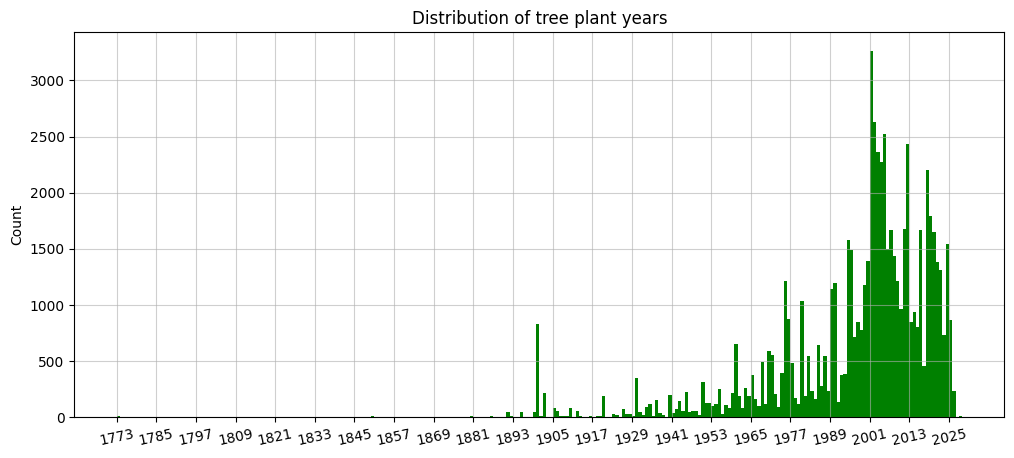

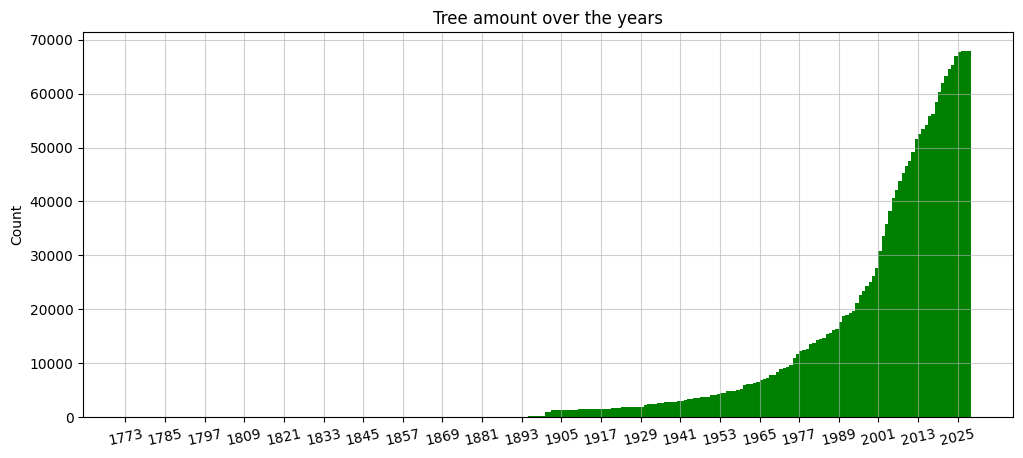

In [257]:
plant_years = df.loc[:, "planteaar"]
plant_years.replace(2027, 2026, inplace=True)
oldest_tree_year = min(plant_years)
youngest_tree_year = max(plant_years)
plant_year_range = youngest_tree_year-oldest_tree_year

plt.figure(figsize=[12, 5])
plt.hist(plant_years, bins=int(plant_year_range), color="green")
plt.title("Distribution of tree plant years")
plt.ylabel("Count")
plt.xticks(np.arange(oldest_tree_year, youngest_tree_year, step=12), rotation=12)
plt.grid(alpha=0.6)
plt.savefig("../data/full_dist.png")
plt.show()

plt.figure(figsize=[12, 5])
plt.hist(plant_years, bins=int(plant_year_range), color="green", cumulative=True)
plt.title("Tree amount over the years")
plt.ylabel("Count")
plt.xticks(np.arange(oldest_tree_year, youngest_tree_year, step=12), rotation=12)
plt.grid(alpha=0.6)
plt.savefig("../data/full_cumu.png")
plt.show()